In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.optimize import brentq
from specparam import SpectralModel
from specparam.measures.pointwise import compute_pointwise_error_arr

rng = np.random.default_rng(42)


Simulations for two arguments about specparam geometry:

Quadratic residual diagnostic:
Fit aperiodic component with specparam (fixed mode), then fit a quadratic
to the signed residuals (log10 data minus aperiodic fit).
The sign and magnitude of q diagnoses curvature:

|q| < Q_DOUBT  → fixed mode adequate (pure power law)
q ≪ 0          → concave DOWN in log-log: Lorentzian knee within/below range.
              Consider using knee mode.
q ≫ 0          → concave UP in log-log: flat floor at high frequencies.
              Consistent with EMG contamination or a second Lorentzian.





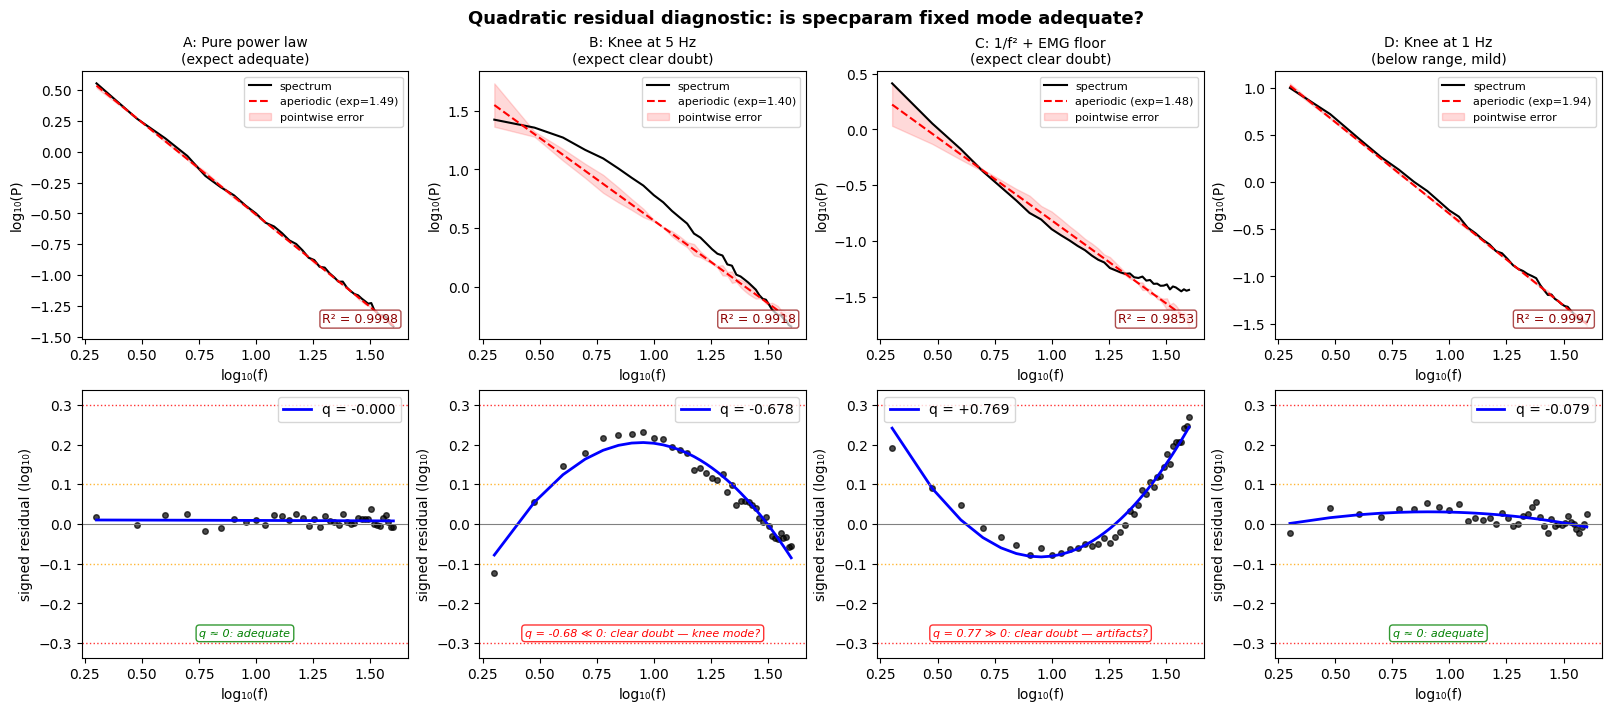

Part 1: Quadratic residual diagnostic (specparam fixed mode)
  thresholds: Q_MILD=0.1, Q_DOUBT=0.3
  A: Pure power law                    q = -0.0004  R² = 0.9998  [adequate]
  B: Knee at 5 Hz                      q = -0.6778  R² = 0.9918  [clear doubt: knee?]
  C: 1/f² + EMG floor                  q = +0.7691  R² = 0.9853  [clear doubt: EMG?]
  D: Knee at 1 Hz                      q = -0.0792  R² = 0.9997  [adequate]



In [6]:
# ── Helpers ────────────────────────────────────────────────────────────

def fit_specparam_aperiodic(freqs, spectrum, freq_range=[2, 40]):
    """Fit aperiodic component using specparam fixed mode.

    Parameters
    ----------
    freqs : 1d array
        Frequency values in Hz (linear scale).
    spectrum : 1d array
        Power values in LINEAR scale (not log).
    freq_range : list
        [min_freq, max_freq] for fitting.

    Returns
    -------
    x          : log10(freqs) over fitted range
    y          : log10(spectrum) over fitted range  (sm.data.power_spectrum)
    y_fit      : aperiodic-only fit in log10 space  (sm.results.model._ap_fit)
    abs_errors : |modeled_spectrum - data| at each freq  (compute_pointwise_error_arr)
    params     : [offset, exponent] from specparam  (exponent is positive)
    sm         : the fitted SpectralModel object
    """
    sm = SpectralModel(aperiodic_mode='fixed', verbose=False)
    sm.fit(freqs, spectrum, freq_range=freq_range)
    x          = np.log10(sm.data.freqs)
    y          = sm.data.power_spectrum               # log10, trimmed
    y_fit      = sm.results.model._ap_fit             # log10 aperiodic, trimmed
    abs_errors = compute_pointwise_error_arr(
                     sm.results.model.modeled_spectrum, y)  # |full_model - data|
    offset     = sm.get_params('aperiodic', 'offset')
    exponent   = sm.get_params('aperiodic', 'exponent')
    return x, y, y_fit, abs_errors, [offset, exponent], sm


def quadratic_residual_test(x, residuals):
    coeffs = np.polyfit(x, residuals, 2)
    q = coeffs[0]
    return q, coeffs


# ── Part 1: Quadratic residual diagnostic ──────────────────────────────

Q_MILD  = 0.10   # |q| > Q_MILD  → mild concern
Q_DOUBT = 0.30   # |q| > Q_DOUBT → clear doubt

freqs = np.arange(2, 41, 1.0)
noise = lambda: 10 ** (rng.normal(0, 0.015, len(freqs)))

# A: Pure power law → |q| < Q_MILD
spec_A = 10 ** (1.0 - 1.5 * np.log10(freqs)) * noise()

# B: Lorentzian knee at 5 Hz (within range) → concave DOWN → q ≪ 0
# Spectrum is flat below 5 Hz, decays as ~1/f^2 above
spec_B = (30.0 / (1 + (freqs / 5.0) ** 2)) * noise()

# C: Pure power law + flat EMG floor → concave UP → q ≫ 0
# Neural: steep 1/f^2, EMG: flat additive broadband
neural_C = 10 ** (1.0 - 2.0 * np.log10(freqs))
emg_floor = 0.03
spec_C = (neural_C + emg_floor) * noise()

# D: Lorentzian knee at 1 Hz (below range) → subtle concave DOWN → q slightly < 0
spec_D = (50.0 / (1 + (freqs / 1.0) ** 2)) * noise()

scenarios = [
    ("A: Pure power law\n(expect adequate)", spec_A),
    ("B: Knee at 5 Hz\n(expect clear doubt)", spec_B),
    ("C: 1/f\u00b2 + EMG floor\n(expect clear doubt)", spec_C),
    ("D: Knee at 1 Hz\n(below range, mild)", spec_D),
]

# ── First pass: collect all residuals to set a shared y-axis range ──
all_residuals = []
fits = []
for label, spec in scenarios:
    x, y, y_fit, abs_errors, aperiodic_params, sm = fit_specparam_aperiodic(freqs, spec)
    r2 = sm.get_metrics('gof', 'rsquared')
    residuals = y - y_fit
    q, quad_coeffs = quadratic_residual_test(x, residuals)
    all_residuals.append(residuals)
    fits.append((x, y, y_fit, abs_errors, aperiodic_params, r2, residuals, q, quad_coeffs))

res_max = max(np.abs(r).max() for r in all_residuals) * 1.25
res_ylim = (-res_max, res_max)

# ── Plot ──
fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)

for i, ((label, spec), (x, y, y_fit, abs_errors, aperiodic_params, r2, residuals, q, quad_coeffs)) \
        in enumerate(zip(scenarios, fits)):

    quad_fit = np.polyval(quad_coeffs, x)

    ax = axes[0, i]
    ax.plot(x, y, "k-", lw=1.5, label="spectrum")
    ax.plot(x, y_fit, "r--", lw=1.5,
            label=f"aperiodic (exp={aperiodic_params[1]:.2f})")
    ax.fill_between(x, y_fit - abs_errors, y_fit + abs_errors,
                    alpha=0.15, color="red", label="pointwise error")
    ax.set_xlabel("log\u2081\u2080(f)")
    ax.set_ylabel("log\u2081\u2080(P)")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.annotate(f"R\u00b2 = {r2:.4f}", xy=(0.97, 0.06), xycoords="axes fraction",
                ha="right", fontsize=9, color="darkred",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="darkred", alpha=0.7))

    ax = axes[1, i]
    ax.plot(x, residuals, "ko", ms=4, alpha=0.7)
    ax.plot(x, quad_fit, "b-", lw=2, label=f"q = {q:+.3f}")
    ax.axhline(0, color="gray", ls="-", lw=0.8)
    ax.axhline( Q_MILD,  color="orange", ls=":", lw=1.0, alpha=0.8)
    ax.axhline(-Q_MILD,  color="orange", ls=":", lw=1.0, alpha=0.8)
    ax.axhline( Q_DOUBT, color="red",    ls=":", lw=1.0, alpha=0.8)
    ax.axhline(-Q_DOUBT, color="red",    ls=":", lw=1.0, alpha=0.8)
    ax.set_ylim(res_ylim)
    ax.set_xlabel("log\u2081\u2080(f)")
    ax.set_ylabel("signed residual (log\u2081\u2080)")
    ax.legend(fontsize=10)

    abs_q = abs(q)
    if abs_q < Q_MILD:
        verdict = "q \u2248 0: adequate"
        color = "green"
    elif abs_q < Q_DOUBT:
        verdict = f"q = {q:.2f}: mild concern"
        color = "orange"
    elif q < 0:
        verdict = f"q = {q:.2f} \u226a 0: clear doubt \u2014 knee mode?"
        color = "red"
    else:
        verdict = f"q = {q:.2f} \u226b 0: clear doubt \u2014 artifacts?"
        color = "red"
    ax.annotate(verdict, xy=(0.5, 0.08), xycoords="axes fraction",
                ha="center", fontsize=8, fontstyle="italic", color=color,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8))

fig.suptitle("Quadratic residual diagnostic: is specparam fixed mode adequate?",
             fontsize=13, fontweight="bold")
fig.savefig("fig1_quadratic_residual.png", dpi=150)
plt.show()

print("=" * 60)
print("Part 1: Quadratic residual diagnostic (specparam fixed mode)")
print(f"  thresholds: Q_MILD={Q_MILD}, Q_DOUBT={Q_DOUBT}")
print("=" * 60)
for (label, spec), (x, y, y_fit, _, _, r2, residuals, q, _) in zip(scenarios, fits):
    abs_q = abs(q)
    if abs_q < Q_MILD:
        flag = "adequate"
    elif abs_q < Q_DOUBT:
        flag = "mild concern"
    else:
        flag = "clear doubt: knee?" if q < 0 else "clear doubt: EMG?"
    short = label.split("\n")[0]
    print(f"  {short:35s}  q = {q:+.4f}  R\u00b2 = {r2:.4f}  [{flag}]")
print()


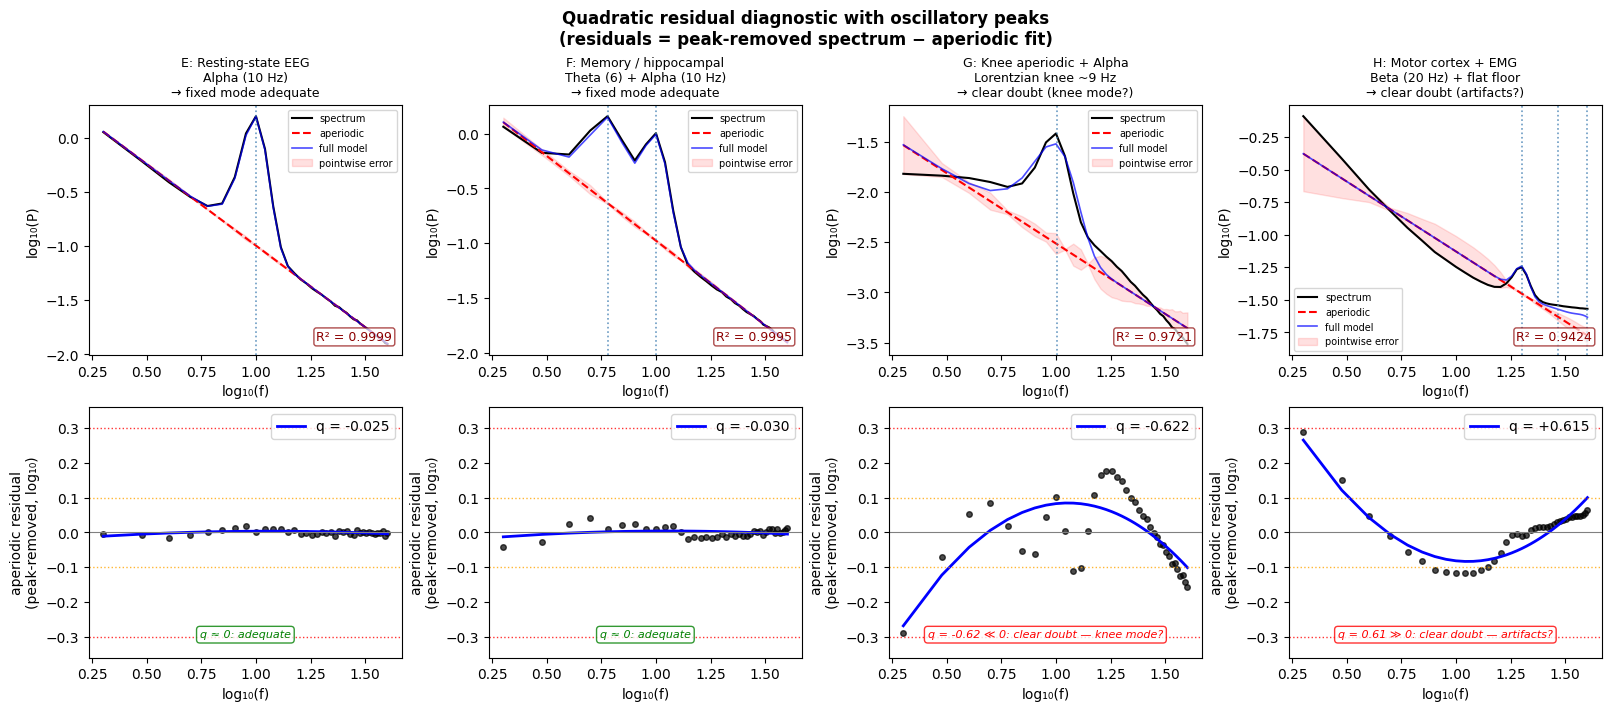

Part 1b: Oscillatory scenarios — aperiodic diagnostic
  thresholds: Q_MILD=0.1, Q_DOUBT=0.3
  residuals = _spectrum_peak_rm − _ap_fit  (peak-removed aperiodic test)
  E: Resting-state EEG                 q=-0.0253  R²=0.9999  peaks=[10.0]  [adequate]
  F: Memory / hippocampal              q=-0.0296  R²=0.9995  peaks=[6.0, 10.0]  [adequate]
  G: Knee aperiodic + Alpha            q=-0.6222  R²=0.9721  peaks=[10.1]  [clear doubt: knee?]
  H: Motor cortex + EMG                q=+0.6149  R²=0.9424  peaks=[20.0, 29.4, 40.0]  [clear doubt: EMG?]



In [7]:
# ── Part 1b: Oscillatory signals — diagnostic across brain-state scenarios ─────────────
#
# Uses specparam.sim to generate realistic power spectra with oscillatory peaks.
#
# KEY DIFFERENCE from Part 1: residuals for the quadratic test are
#   _spectrum_peak_rm  −  _ap_fit
# i.e. the spectrum with peaks removed minus the aperiodic fit.
# This isolates aperiodic curvature from oscillatory structure, so the diagnostic
# correctly tests the aperiodic model even when peaks are present.
#
# Contrast with Part 1 which used  y − y_fit = _spectrum_flat = data − _ap_fit,
# valid there because those spectra had no peaks.

from specparam.sim import sim_power_spectrum

SIM_RANGE = [1, 50]    # wider range for simulation
FIT_RANGE = [2, 40]    # same fitting window as Part 1

# ── Scenario definitions ──────────────────────────────────────────────────────────────
# Each tuple: (label, aperiodic_params_dict, periodic_params_dict, nlv, emg_floor)
# aperiodic: {'fixed': [offset, exp]}  or  {'knee': [offset, knee, exp]}
# periodic:  {'gaussian': [cf, pw, bw, ...]}   (each peak: CF Hz, power log, BW Hz)

osc_scenarios = [
    (
        "E: Resting-state EEG\nAlpha (10 Hz)\n\u2192 fixed mode adequate",
        {"fixed": [0.5, 1.5]},
        {"gaussian": [10, 1.2, 1.5]},
        0.005, 0.0,
    ),
    (
        "F: Memory / hippocampal\nTheta (6) + Alpha (10 Hz)\n\u2192 fixed mode adequate",
        {"fixed": [0.5, 1.5]},
        {"gaussian": [6, 0.8, 1.2, 10, 1.0, 1.5]},
        0.005, 0.0,
    ),
    (
        "G: Knee aperiodic + Alpha\nLorentzian knee ~9 Hz\n\u2192 clear doubt (knee mode?)",
        {"knee": [0.5, 200, 2.5]},
        {"gaussian": [10, 0.8, 1.5]},
        0.005, 0.0,
    ),
    (
        "H: Motor cortex + EMG\nBeta (20 Hz) + flat floor\n\u2192 clear doubt (artifacts?)",
        {"fixed": [0.5, 2.0]},
        {"gaussian": [20, 0.6, 2.0]},
        0.005, 0.025,   # flat additive floor in linear power
    ),
]

# ── First pass: fit all, collect aperiodic residuals for shared y-axis ───────────────
osc_fits = []
osc_aperiodic_resids = []

for label, ap_params, per_params, nlv, emg in osc_scenarios:
    freqs_s, powers_s = sim_power_spectrum(
        SIM_RANGE, ap_params, per_params, nlv=nlv, freq_res=1.0
    )
    if emg > 0:
        powers_s = powers_s + emg          # additive flat floor in linear space

    sm = SpectralModel(aperiodic_mode='fixed', verbose=False, max_n_peaks=6)
    sm.fit(freqs_s, powers_s, freq_range=FIT_RANGE)

    x         = np.log10(sm.data.freqs)
    y         = sm.data.power_spectrum             # log10 data, trimmed
    y_fit     = sm.results.model._ap_fit           # log10 aperiodic fit
    full_fit  = sm.results.model.modeled_spectrum  # log10 aperiodic + peaks
    abs_err   = compute_pointwise_error_arr(full_fit, y)
    r2        = sm.get_metrics('gof', 'rsquared')

    # Aperiodic residuals: peak-removed spectrum minus aperiodic fit
    # = (data − peaks) − aperiodic  →  tests aperiodic shape independent of peaks
    ap_resid = sm.results.model._spectrum_peak_rm - y_fit
    q, quad_coeffs = quadratic_residual_test(x, ap_resid)

    # Detected peak centre frequencies
    peak_params = sm.results.params.periodic.params
    peak_cfs    = peak_params[:, 0] if len(peak_params) > 0 else []

    osc_aperiodic_resids.append(ap_resid)
    osc_fits.append((x, y, y_fit, full_fit, abs_err, r2, ap_resid, q, quad_coeffs, peak_cfs))

res_max_osc = max(np.abs(r).max() for r in osc_aperiodic_resids) * 1.25
res_ylim_osc = (-res_max_osc, res_max_osc)

# ── Plot ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)

for i, ((label, *_), (x, y, y_fit, full_fit, abs_err, r2,
                       ap_resid, q, quad_coeffs, peak_cfs)) \
        in enumerate(zip(osc_scenarios, osc_fits)):

    quad_fit = np.polyval(quad_coeffs, x)

    # ── top row: spectrum + fits ──
    ax = axes[0, i]
    ax.plot(x, y, "k-", lw=1.5, label="spectrum")
    ax.plot(x, y_fit, "r--", lw=1.5, label="aperiodic")
    ax.plot(x, full_fit, "b-", lw=1.2, alpha=0.7, label="full model")
    ax.fill_between(x, y_fit - abs_err, y_fit + abs_err,
                    alpha=0.12, color="red", label="pointwise error")
    # mark detected peaks as vertical lines
    for cf in peak_cfs:
        ax.axvline(np.log10(cf), color="steelblue", ls=":", lw=1.2, alpha=0.8)
    ax.set_xlabel("log\u2081\u2080(f)")
    ax.set_ylabel("log\u2081\u2080(P)")
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)
    ax.annotate(f"R\u00b2 = {r2:.4f}", xy=(0.97, 0.06), xycoords="axes fraction",
                ha="right", fontsize=9, color="darkred",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="darkred", alpha=0.7))

    # ── bottom row: aperiodic residuals ──
    ax = axes[1, i]
    ax.plot(x, ap_resid, "ko", ms=4, alpha=0.7)
    ax.plot(x, quad_fit, "b-", lw=2, label=f"q = {q:+.3f}")
    ax.axhline(0, color="gray", ls="-", lw=0.8)
    ax.axhline( Q_MILD,  color="orange", ls=":", lw=1.0, alpha=0.8)
    ax.axhline(-Q_MILD,  color="orange", ls=":", lw=1.0, alpha=0.8)
    ax.axhline( Q_DOUBT, color="red",    ls=":", lw=1.0, alpha=0.8)
    ax.axhline(-Q_DOUBT, color="red",    ls=":", lw=1.0, alpha=0.8)
    ax.set_ylim(res_ylim_osc)
    ax.set_xlabel("log\u2081\u2080(f)")
    ax.set_ylabel("aperiodic residual\n(peak-removed, log\u2081\u2080)")
    ax.legend(fontsize=10)

    abs_q = abs(q)
    if abs_q < Q_MILD:
        verdict = "q \u2248 0: adequate"
        color = "green"
    elif abs_q < Q_DOUBT:
        verdict = f"q = {q:.2f}: mild concern"
        color = "orange"
    elif q < 0:
        verdict = f"q = {q:.2f} \u226a 0: clear doubt \u2014 knee mode?"
        color = "red"
    else:
        verdict = f"q = {q:.2f} \u226b 0: clear doubt \u2014 artifacts?"
        color = "red"
    ax.annotate(verdict, xy=(0.5, 0.08), xycoords="axes fraction",
                ha="center", fontsize=8, fontstyle="italic", color=color,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8))

fig.suptitle(
    "Quadratic residual diagnostic with oscillatory peaks\n"
    "(residuals = peak-removed spectrum \u2212 aperiodic fit)",
    fontsize=12, fontweight="bold",
)
fig.savefig("fig1b_oscillatory_diagnostic.png", dpi=150)
plt.show()

print("=" * 70)
print("Part 1b: Oscillatory scenarios — aperiodic diagnostic")
print(f"  thresholds: Q_MILD={Q_MILD}, Q_DOUBT={Q_DOUBT}")
print("  residuals = _spectrum_peak_rm − _ap_fit  (peak-removed aperiodic test)")
print("=" * 70)
for (label, *_), (x, y, y_fit, _, _, r2, ap_resid, q, _, peak_cfs) in zip(osc_scenarios, osc_fits):
    abs_q = abs(q)
    if abs_q < Q_MILD:
        flag = "adequate"
    elif abs_q < Q_DOUBT:
        flag = "mild concern"
    else:
        flag = "clear doubt: knee?" if q < 0 else "clear doubt: EMG?"
    short = label.split("\n")[0]
    cfs_str = ", ".join(f"{cf:.1f}" for cf in peak_cfs) if len(peak_cfs) else "none"
    print(f"  {short:35s}  q={q:+.4f}  R\u00b2={r2:.4f}  peaks=[{cfs_str}]  [{flag}]")
print()
